# Statistical and Initial Data Analysis Plan
### SAP - Test data prediction
- WHAT: Predict which remaining 1/3rd of the passengers have been transported to another dimension
- WHO: Passengers belonging to the missing 1/3rd of the dataset
- FEATURES: Everything besides HomePlanet and Destination columns
- PREDICTOR: Transported
- CLEANING NULLS:
    - MCAR - Impute, drop rows/columns
    - MAR - KNNImputer, multivariate imputation modes\ls
    - MNAR - Flag to keep data, do not remove
- VALIDATE: Split training dataset 80/20 and assess accuracy

### IAP - Training data exploration (EDA + Feat ENG)
- Meta data: Data about data collection
    - describe()
    - shape()
    - isna().sum()
    - head(), tail()
    - info() - check data types
- Data cleaning: Correcting inaccurate
    - IQR + box plot - find outliers
    - One Hot Encoding 
- Data screening (properties): Checking data properties
- Reporting: structured report 



In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub 
from ydata_profiling import ProfileReport
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

/tmp/ipykernel_16/472091099.py:7: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [2]:
# load the data
df = pd.read_csv("/kaggle/input/competitions/spaceship-titanic/train.csv")
df_test = pd.read_csv("/kaggle/input/competitions/spaceship-titanic/test.csv")

# generate the report
profile = ProfileReport(df, title="Spaceship Titanic Profile")
#profile.to_notebook_iframe()

In [3]:
# inspect the data
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [4]:
df.shape

(8693, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [6]:
# number of unique elements in dataset
df.nunique()

PassengerId     8693
HomePlanet         3
CryoSleep          2
Cabin           6560
Destination        3
Age               80
VIP                2
RoomService     1273
FoodCourt       1507
ShoppingMall    1115
Spa             1327
VRDeck          1306
Name            8473
Transported        2
dtype: int64

In [7]:
df.describe(include='all')

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
count,8693,8492,8476,8494,8511,8514.000000,8490,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000,8493,8693
unique,8693,3,2,6560,3,NaN,2,NaN,NaN,NaN,NaN,NaN,8473,2
top,0001_01,Earth,False,G/734/S,TRAPPIST-1e,NaN,False,NaN,NaN,NaN,NaN,NaN,Ankalik Nateansive,True
freq,1,4602,5439,8,5915,NaN,8291,NaN,NaN,NaN,NaN,NaN,2,4378
mean,NaN,NaN,NaN,NaN,NaN,28.827930,NaN,224.687617,458.077203,173.729169,311.138778,304.854791,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,14.489021,NaN,666.717663,1611.489240,604.696458,1136.705535,1145.717189,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,19.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,27.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,38.000000,NaN,47.000000,76.000000,27.000000,59.000000,46.000000,NaN,NaN


In [8]:
# data transform
imputer = KNNImputer(n_neighbors=5)

df.isna().sum()


df.fillna({
    'Age': df['Age'].median(),
    'RoomService': df['RoomService'].median(),
    'FoodCourt': df['FoodCourt'].median(),
    'ShoppingMall': df['ShoppingMall'].median(),
    'Spa': df['Spa'].median(),
    'VRDeck': df['VRDeck'].median(),
}, inplace=True)

df = df.drop(columns=['Name', 'Destination', 'HomePlanet', 'Cabin', 'PassengerId'])
     
df = pd.get_dummies(df, columns=['VIP', 'CryoSleep'], dtype=int)

imputer.fit_transform(df)

array([[3.900e+01, 0.000e+00, 0.000e+00, ..., 0.000e+00, 1.000e+00,
        0.000e+00],
       [2.400e+01, 1.090e+02, 9.000e+00, ..., 0.000e+00, 1.000e+00,
        0.000e+00],
       [5.800e+01, 4.300e+01, 3.576e+03, ..., 1.000e+00, 1.000e+00,
        0.000e+00],
       ...,
       [2.600e+01, 0.000e+00, 0.000e+00, ..., 0.000e+00, 1.000e+00,
        0.000e+00],
       [3.200e+01, 0.000e+00, 1.049e+03, ..., 0.000e+00, 1.000e+00,
        0.000e+00],
       [4.400e+01, 1.260e+02, 4.688e+03, ..., 0.000e+00, 1.000e+00,
        0.000e+00]], shape=(8693, 11))

In [9]:
scaler = StandardScaler()

scaler_data = scaler.fit_transform(df)

print(scaler_data)

[[ 0.71194537 -0.33310466 -0.28102673 ... -0.15306307  0.77348028
  -0.73277002]
 [-0.33403748 -0.16807343 -0.27538657 ... -0.15306307  0.77348028
  -0.73277002]
 [ 2.03685698 -0.2680006   1.95999765 ...  6.53325471  0.77348028
  -0.73277002]
 ...
 [-0.1945731  -0.33310466 -0.28102673 ... -0.15306307  0.77348028
  -0.73277002]
 [ 0.22382004 -0.33310466  0.37636549 ... -0.15306307  0.77348028
  -0.73277002]
 [ 1.06060632 -0.14233462  2.656871   ... -0.15306307  0.77348028
  -0.73277002]]


In [10]:
df.isna().sum()

# CryoSleep, VIP,  KNN Imputer
# VIP individuals likely will be spending the most
# CryoSleep will probably not be spending anything @ all

Age                0
RoomService        0
FoodCourt          0
ShoppingMall       0
Spa                0
VRDeck             0
Transported        0
VIP_False          0
VIP_True           0
CryoSleep_False    0
CryoSleep_True     0
dtype: int64

Text(0.5, 1.0, 'Histogram of Age')

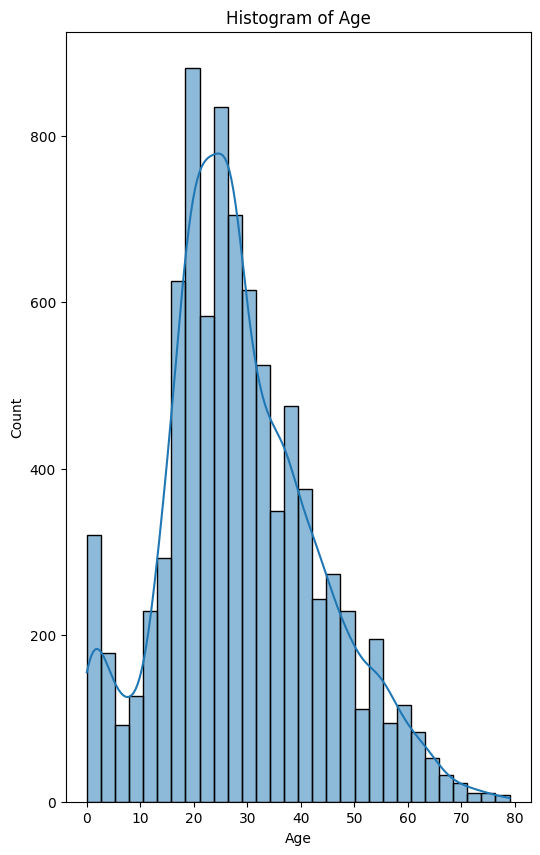

In [11]:
# univariate analysis

fig, axes = plt.subplots(1, 1, figsize=(6, 10))

sns.histplot(df['Age'], bins=30, kde=True, ax=axes)
axes.set_title("Histogram of Age")


<Axes: xlabel='Age', ylabel='RoomService'>

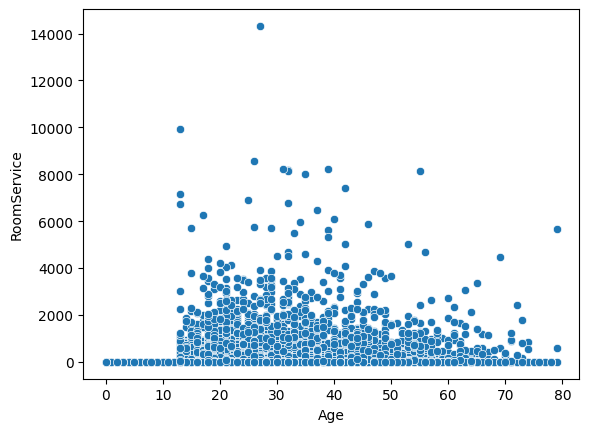

In [12]:
# bivariate analysis

sns.scatterplot(x="Age", y="RoomService", data=df)

<Axes: xlabel='Age', ylabel='FoodCourt'>

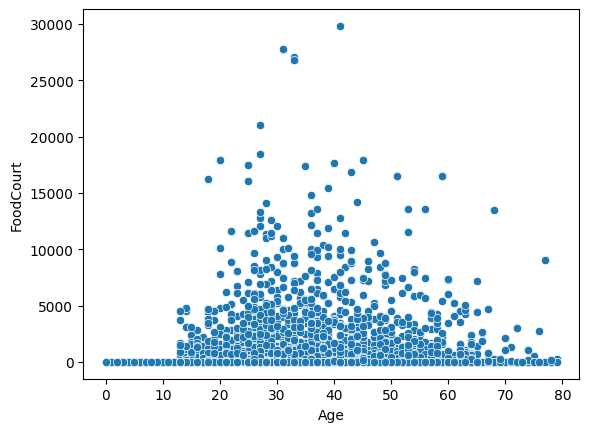

In [13]:
sns.scatterplot(x="Age", y="FoodCourt", data=df)

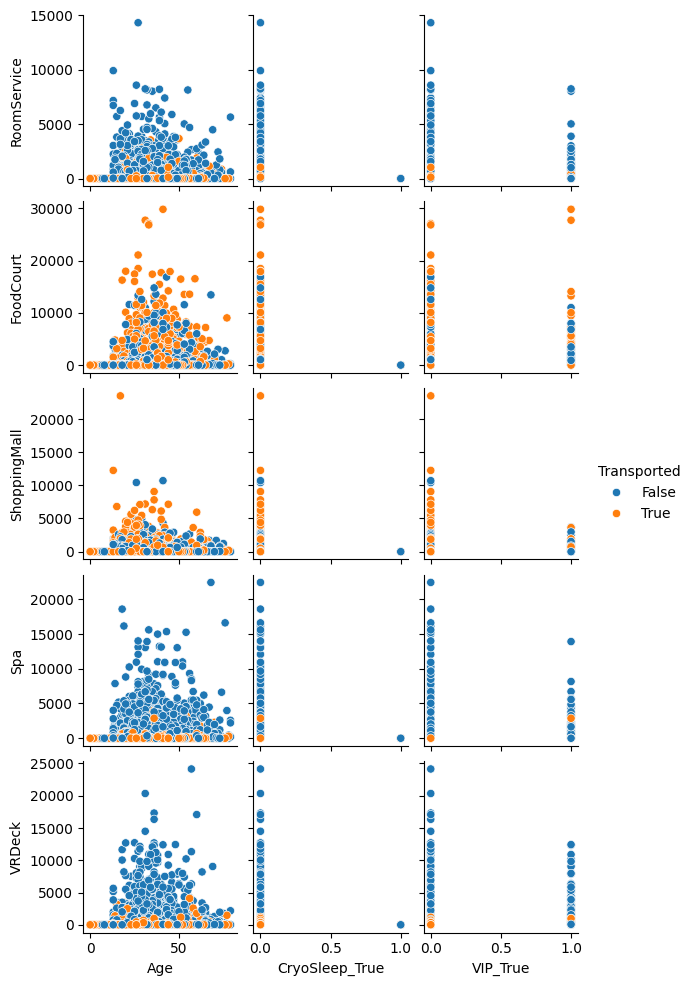

In [14]:
#multivariate analysis
sns.pairplot(
    df, 
    kind='scatter',
    x_vars=['Age', 'CryoSleep_True', 'VIP_True'],
    y_vars=['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'],
    hue='Transported',
    height=2
)

Text(0.5, 1.0, 'Age Outliers')

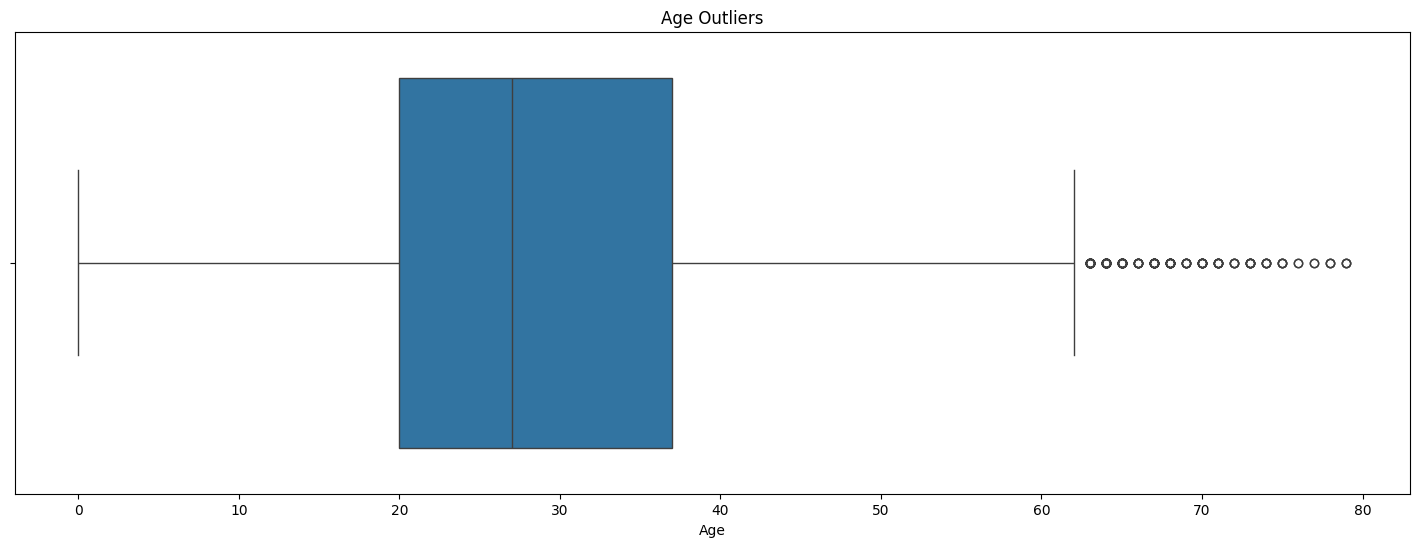

In [15]:
# handling outliers

# calculate IQR ranges
q1_age = df['Age'].quantile(0.25)
q3_age = df['Age'].quantile(0.75)
iqr_age = q3_age - q1_age

# finding outliers based on IQR
age_outliers = df[(df['Age'] < (q1_age - 1.5 * iqr_age)) | (df['Age'] > (q3_age + 1.5 * iqr_age))]

fig, axes = plt.subplots(1,1,figsize=(18,6))
sns.boxplot(x=df['Age'])
axes.set_title('Age Outliers')

Text(0.5, 1.0, 'Age Outliers')

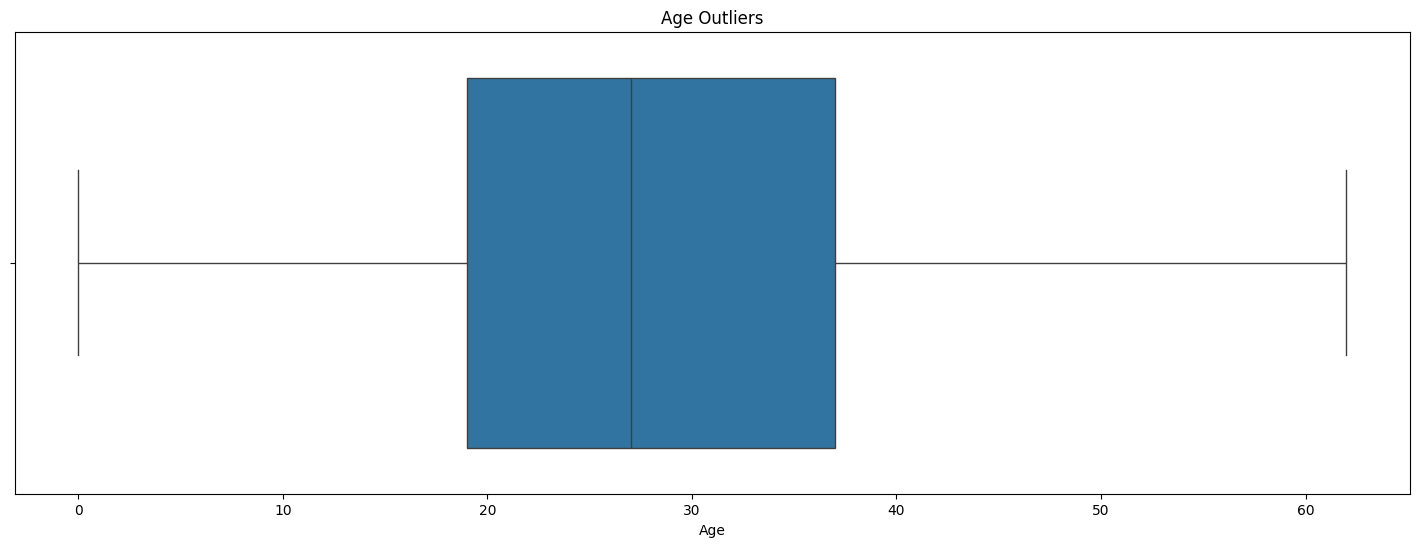

In [16]:
# removing age outliers from dataset
df = df[(df['Age'] > q1_age - 1.5 * iqr_age) & (df['Age'] < q3_age + 1.5 * iqr_age)]

# verifying dataset by plotting
fig, axes = plt.subplots(1,1,figsize=(18,6))
sns.boxplot(x=df['Age'])
axes.set_title('Age Outliers')

<Axes: >

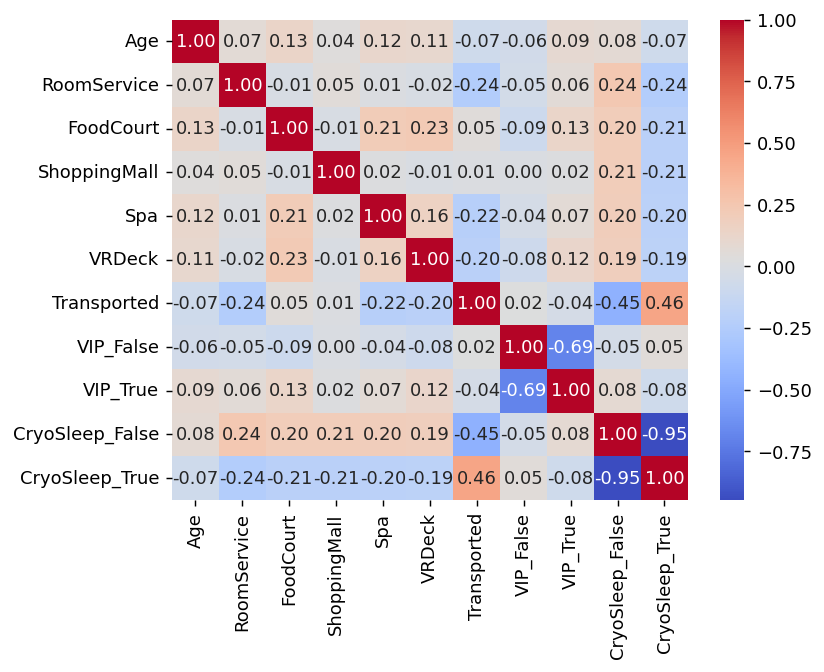

In [17]:
# Correlation Analysis + heatmap

corr = df.corr()
plt.figure(dpi=130)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')

In [18]:
# print the highest correlations for "Transported"

print(corr['Transported'].sort_values(ascending=False))

Transported        1.000000
CryoSleep_True     0.457911
FoodCourt          0.045982
VIP_False          0.021649
ShoppingMall       0.009538
VIP_True          -0.036884
Age               -0.074619
VRDeck            -0.204630
Spa               -0.220508
RoomService       -0.240705
CryoSleep_False   -0.449745
Name: Transported, dtype: float64


Seems like those who were in cryosleep or in the food court had a higher chance of being Transported.

In [19]:
# Transforming test data

df_test.isna().sum()


df_test.fillna({
    'Age': df_test['Age'].median(),
    'RoomService': df_test['RoomService'].median(),
    'FoodCourt': df_test['FoodCourt'].median(),
    'ShoppingMall': df_test['ShoppingMall'].median(),
    'Spa': df_test['Spa'].median(),
    'VRDeck': df_test['VRDeck'].median(),
}, inplace=True)

df_test = df_test.drop(columns=['Name', 'Destination', 'HomePlanet', 'Cabin', 'PassengerId'])
     
df_test = pd.get_dummies(df_test, columns=['VIP', 'CryoSleep'], dtype=int)

imputer.fit_transform(df_test)

array([[2.70e+01, 0.00e+00, 0.00e+00, ..., 0.00e+00, 0.00e+00, 1.00e+00],
       [1.90e+01, 0.00e+00, 9.00e+00, ..., 0.00e+00, 1.00e+00, 0.00e+00],
       [3.10e+01, 0.00e+00, 0.00e+00, ..., 0.00e+00, 0.00e+00, 1.00e+00],
       ...,
       [2.60e+01, 0.00e+00, 0.00e+00, ..., 0.00e+00, 0.00e+00, 1.00e+00],
       [2.60e+01, 0.00e+00, 2.68e+03, ..., 0.00e+00, 1.00e+00, 0.00e+00],
       [4.30e+01, 0.00e+00, 0.00e+00, ..., 0.00e+00, 0.00e+00, 1.00e+00]],
      shape=(4277, 10))

In [20]:
# read in data
X = df.drop(columns='Transported')
y = df['Transported']
dtrain = xgb.DMatrix(X, label=y)
dtest = xgb.DMatrix(df_test)

# specify parameters via map
param = {'max_depth':2, 'eta':1, 'objective':'binary:logistic' }
num_round = 2
bst = xgb.train(param, dtrain, num_round)

# make prediction
preds = bst.predict(dtest)
preds = np.round(preds).astype(int)

print(preds)

[1 0 1 ... 1 0 1]
